# 09 — Intercalibración radiométrica GOES-16 / GOES-19

El conjunto de datos satelital combina imágenes de dos instrumentos. GOES-16 cubre todo 2024, que incluye los conjuntos de entrenamiento y validación, y el primer trimestre de 2025; GOES-19 cubre el resto de 2025, a partir del 4 de abril a las 15:10 UTC, instante en que el registro cambia de fuente. El conjunto de prueba reúne así imágenes de ambos satélites, con predominio de GOES-19. Los dos comparten el diseño del instrumento (ABI) y la posición orbital nominal (75.2°O), pero pequeñas diferencias en su calibración radiométrica podrían introducir un sesgo sistemático entre las temperaturas de brillo de una fuente y la otra.

Si ese sesgo existe y no se corrige, el modelo podría aprender, al menos en parte, a distinguir el satélite que tomó la imagen en lugar de las condiciones atmosféricas precursoras de lluvia fuerte, y su desempeño en el conjunto de prueba mezclaría ambos efectos. Esta notebook verifica si ese riesgo es real antes de que los parches entren al pipeline de entrenamiento.

**Estrategia**

Una comparación entre imágenes de períodos distintos no permite separar un sesgo instrumental de la variabilidad atmosférica, porque ambos producen el mismo síntoma: diferencias entre las distribuciones de temperatura de brillo. La transición entre satélites ofrece, sin embargo, una ventana en la que esa separación es directa. GOES-19 asumió oficialmente como satélite GOES-East el 7 de abril de 2025 a las 15:10 UTC, fecha que corrigió el 4 de abril anunciado inicialmente, y ambos satélites publicaron datos de disco completo entre el 4 y el 7 de abril. Durante ese período los dos instrumentos observaron la misma escena en el mismo instante, de modo que cualquier diferencia sistemática entre sus imágenes corresponde al instrumento y no a la atmósfera.

La comparación se realiza sobre el recorte del dominio de estudio, construido con el mismo procedimiento que el registro descargado, y aprovecha además una verificación de procedencia: en cada instante, el archivo del registro debe coincidir exactamente con el recorte de uno de los dos satélites.

**Output**

|Archivo|Descripción|
|-|-|
|`intercalibracion_simultanea.parquet`|Medianas y diferencias por banda de los pares simultáneos GOES-16 / GOES-19|
|`img-intercalibracion_simultanea.png`|Mediana de escena GOES-19 frente a GOES-16, por banda|
|`intercalibracion_coeficientes.csv`|Diferencia entre instrumentos, desplazamiento en desvíos estándar y offset por banda|

El archivo de coeficientes es consumido por `10-goes_patches.ipynb` antes de aplicar la normalización z-score.

In [ ]:
# Configuración --------------------------------------------------------------

from pathlib import Path
import re
import sys
from concurrent.futures import ThreadPoolExecutor
from functools import lru_cache

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
from pyproj import Proj
from tqdm import tqdm

RUTA_BASE  = Path(r"C:\Users\diani\Documents\repositories\nowcasting-bogota")
RUTA_SAT   = RUTA_BASE / "data_ingestion" / "satellite"
RUTA_INV   = RUTA_SAT / "inventario_goes.parquet"
RUTA_SIMUL = RUTA_SAT / "intercalibracion_simultanea.parquet"   # caché de la comparación

sys.path.append(str(RUTA_BASE / "src"))
from paleta import PALETA, ROL, aplicar_estilo
aplicar_estilo()

BANDAS     = ["CMI_C08", "CMI_C09", "CMI_C10", "CMI_C13", "CMI_C14"]
TRANSICION = pd.Timestamp("2025-04-04 15:10")   # corte del registro en download_cmip.py (UTC sin zona)
RECALCULAR = False

inv = pd.read_parquet(RUTA_INV)
assert inv["timestamp"].dt.tz is None

## Sección 1 — Comparación simultánea GOES-16 / GOES-19

Se toma un instante por hora entre el 4 de abril a las 00:00 y el 7 de abril a las 18:00 UTC, el período en que ambos buckets de NOAA contienen el producto de disco completo, lo que da 91 pares de imágenes simultáneas. Para cada instante y banda se lee, directamente desde el repositorio de NOAA, el recorte del dominio de cada satélite, con la misma geometría que emplea el procedimiento de descarga. Sobre cada par se calcula la diferencia entre las medianas de la escena y la diferencia media píxel a píxel, ambas como GOES-19 menos GOES-16. En los instantes presentes en el registro, el archivo descargado se compara además con los dos recortes para identificar su origen. Como las dos imágenes de cada par proceden del mismo escaneo nominal, las diferencias no dependen de la evolución de la atmósfera.

In [ ]:
fs = s3fs.S3FileSystem(anon=True)
dias = {"094": "04-abr", "095": "05-abr", "096": "06-abr", "097": "07-abr", "098": "08-abr"}  # día juliano 2025

for bucket in ["noaa-goes16", "noaa-goes19"]:
    for dj, etiqueta in dias.items():
        n = len(fs.glob(f"{bucket}/ABI-L2-CMIPF/2025/{dj}/*/*M6C13*"))
        print(f"{bucket}  {etiqueta}: {n:>4} archivos C13")

noaa-goes16  04-abr:  144 archivos C13
noaa-goes16  05-abr:  144 archivos C13
noaa-goes16  06-abr:  144 archivos C13
noaa-goes16  07-abr:  112 archivos C13
noaa-goes16  08-abr:    0 archivos C13
noaa-goes19  04-abr:  144 archivos C13
noaa-goes19  05-abr:  144 archivos C13
noaa-goes19  06-abr:  144 archivos C13
noaa-goes19  07-abr:  144 archivos C13
noaa-goes19  08-abr:  144 archivos C13


In [ ]:
BOUND         = {"lon": [-75.877, -72.277], "lat": [2.796, 6.396]}   # mismo dominio que download_cmip.py
PATRON_INICIO = re.compile(r"_s(\d{13})")
INSTANTES     = pd.date_range("2025-04-04 00:00", "2025-04-07 18:00", freq="h")   # UTC sin zona

@lru_cache(maxsize=None)
def listar(bucket: str, hora: pd.Timestamp) -> tuple:
    return tuple(fs.ls(f"{bucket}/ABI-L2-CMIPF/{hora:%Y}/{hora:%j}/{hora:%H}/"))

def archivo_noaa(bucket: str, t: pd.Timestamp, canal: str) -> str | None:
    """Archivo de la banda cuyo escaneo inicia en [t, t + 10 min); None si no hay exactamente uno."""
    cands = [f for f in listar(bucket, t.floor("h"))
             if re.search(rf"-M\dC{canal}_", f)
             and t <= pd.to_datetime(PATRON_INICIO.search(f).group(1), format="%Y%j%H%M%S") < t + pd.Timedelta("10min")]
    return cands[0] if len(cands) == 1 else None

def recorte_remoto(ruta: str) -> tuple[np.ndarray, dict]:
    """Recorte del dominio leído directo desde S3, con la misma geometría que download_cmip.py."""
    with fs.open(ruta, "rb") as fh, xr.open_dataset(fh, engine="h5netcdf") as ds:
        pr = ds["goes_imager_projection"].attrs
        h  = float(np.squeeze(pr["perspective_point_height"]))
        p  = Proj(proj="geos", h=h, lon_0=float(np.squeeze(pr["longitude_of_projection_origin"])),
                  sweep=str(pr["sweep_angle_axis"]))
        xmin, ymin = np.array(p(BOUND["lon"][0], BOUND["lat"][0])) / h
        xmax, ymax = np.array(p(BOUND["lon"][1], BOUND["lat"][1])) / h
        x, y = ds["x"].values, ds["y"].values
        sx, sy = np.where((x >= xmin) & (x <= xmax))[0], np.where((y >= ymin) & (y <= ymax))[0]
        bt = ds["CMI"].isel(y=slice(sy.min(), sy.max() + 1), x=slice(sx.min(), sx.max() + 1)).values
        info = {"subpunto_lon": float(ds["nominal_satellite_subpoint_lon"].values),
                "slot": ds.attrs.get("orbital_slot")}
    return bt.astype("float64"), info

def comparar_instante(t: pd.Timestamp) -> dict | None:
    fila = {"timestamp": t}
    loc = inv[(inv["timestamp"] == t) & ~inv["excluido_qc"]]
    ds_local = xr.open_dataset(loc["filepath"].iloc[0]) if len(loc) else None
    try:
        for b in BANDAS:
            f16, f19 = archivo_noaa("noaa-goes16", t, b[-2:]), archivo_noaa("noaa-goes19", t, b[-2:])
            if f16 is None or f19 is None:
                return None
            bt16, i16 = recorte_remoto(f16)
            bt19, i19 = recorte_remoto(f19)
            fila[f"{b}_med16"]  = float(np.nanmedian(bt16))
            fila[f"{b}_med19"]  = float(np.nanmedian(bt19))
            fila[f"{b}_difpix"] = float(np.nanmean(bt19 - bt16))
            if ds_local is not None:
                bl = ds_local[b].values.astype("float64")
                fila[f"{b}_local"] = ("G16" if np.array_equal(bl, bt16, equal_nan=True) else
                                      "G19" if np.array_equal(bl, bt19, equal_nan=True) else "ninguno")
        fila.update(sub16=i16["subpunto_lon"], sub19=i19["subpunto_lon"],
                    slot16=i16["slot"], slot19=i19["slot"])
        return fila
    finally:
        if ds_local is not None:
            ds_local.close()

if RUTA_SIMUL.exists() and not RECALCULAR:
    simul = pd.read_parquet(RUTA_SIMUL)
else:
    with ThreadPoolExecutor(max_workers=8) as ex:
        filas = list(tqdm(ex.map(comparar_instante, INSTANTES), total=len(INSTANTES), desc="Pares simultáneos"))
    simul = pd.DataFrame([f for f in filas if f is not None])
    simul.to_parquet(RUTA_SIMUL, index=False)

print(f"Pares simultáneos: {len(simul)} de {len(INSTANTES)} instantes")
print("Geometría:", simul[["sub16", "sub19", "slot16", "slot19"]].drop_duplicates().to_string(index=False))

Pares simultáneos: 100%|██████████| 91/91 [1:16:03<00:00, 50.15s/it] 

Pares simultáneos: 91 de 91 instantes
Geometría:      sub16      sub19    slot16    slot19
-75.199997 -75.199997 GOES-East GOES-East


,n,delta_mediana_K,desvio_K,ic95_K,delta_pixel_K,max_abs_K
banda,,,,,,
CMI_C08,91,-0.214,0.061,0.012,-0.197,0.296
CMI_C09,91,0.065,0.068,0.014,0.027,0.212
CMI_C10,91,-0.158,0.067,0.014,-0.159,0.299
CMI_C13,91,-0.056,0.059,0.012,-0.022,0.246
CMI_C14,91,-0.123,0.038,0.008,-0.127,0.180


col_0                 G16  G19
row_0                         
antes 04-abr 15:10     16    0
después 04-abr 15:10    0   75


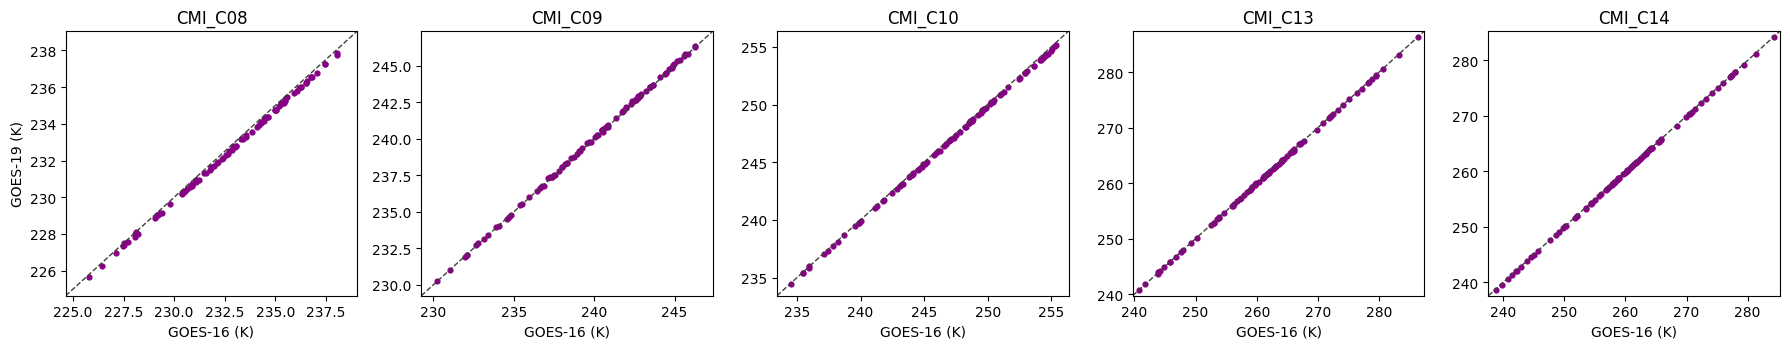

In [ ]:
# ΔBT = G19 − G16 en el mismo instante
filas = []
for b in BANDAS:
    d = simul[f"{b}_med19"] - simul[f"{b}_med16"]
    filas.append({"banda": b, "n": d.size,
                  "delta_mediana_K": d.mean(), "desvio_K": d.std(),
                  "ic95_K": 1.96 * d.std() / np.sqrt(d.size),
                  "delta_pixel_K": simul[f"{b}_difpix"].mean(),
                  "max_abs_K": d.abs().max()})
tabla_simul = pd.DataFrame(filas).set_index("banda").round(3)
display(tabla_simul)

# ¿De qué satélite vienen los archivos locales? Antes y después del corte del registro
antes_corte = np.where(simul["timestamp"] < TRANSICION, "antes 04-abr 15:10", "después 04-abr 15:10")
cols_local = [f"{b}_local" for b in BANDAS]
print(pd.crosstab(antes_corte, simul[cols_local].apply(lambda r: "/".join(sorted(set(r))), axis=1)))

fig, axes = plt.subplots(1, len(BANDAS), figsize=(18, 3.6))
for ax, b in zip(axes, BANDAS):
    ax.scatter(simul[f"{b}_med16"], simul[f"{b}_med19"], s=12, color=ROL["split_test"])
    lims = [simul[[f"{b}_med16", f"{b}_med19"]].min().min() - 1, simul[[f"{b}_med16", f"{b}_med19"]].max().max() + 1]
    ax.plot(lims, lims, color=ROL["linea_ref"], linestyle="--", linewidth=1)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_title(b); ax.set_xlabel("GOES-16 (K)")
axes[0].set_ylabel("GOES-19 (K)")
plt.tight_layout()
plt.show()

Ambos satélites declaran la misma posición nominal (75.2°O) y el mismo slot orbital durante el período de comparación, por lo que las dos imágenes de cada par comparten la geometría de observación. Las diferencias entre instrumentos son de décimas de kelvin: la diferencia media en la mediana de la escena va de −0.21 K en C08 a +0.07 K en C09, con −0.16 K en C10, −0.06 K en C13 y −0.12 K en C14, y ningún instante supera 0.3 K en valor absoluto en ninguna banda. La diferencia píxel a píxel reproduce esos valores, lo que indica un desplazamiento uniforme de la escena y no un efecto concentrado en algunos píxeles. Los intervalos de confianza son estrechos, del orden de ±0.01 K, de manera que algunas de estas diferencias son distinguibles de cero; su magnitud, sin embargo, es despreciable. Dado que los pares horarios consecutivos no son independientes, esos intervalos deben leerse como aproximados.

La figura muestra que los pares se alinean sobre la diagonal en todo el rango de temperaturas observado, desde unos 240 K hasta unos 285 K en las bandas de ventana infrarroja. No hay indicio de una diferencia de ganancia, que se manifestaría como una separación creciente hacia uno de los extremos; el ligero desplazamiento bajo la diagonal en C08 corresponde a los −0.21 K de la tabla.

La verificación de procedencia confirma además la composición del registro: los 16 instantes previos al 4 de abril a las 15:10 UTC coinciden exactamente con GOES-16 y los 75 posteriores con GOES-19. El registro cambia de fuente tres días antes de la fecha operativa oficial, de modo que esos tres días corresponden a datos de GOES-19 en fase preoperativa. Dado que en ese mismo período la diferencia con GOES-16 es de décimas de kelvin, esa anticipación no tiene consecuencias para el conjunto de datos.

In [11]:
# Desplazamiento en unidades de desvío estándar, la escala que ve el modelo tras el z-score.
# σ de la mediana de escena en los 91 instantes: subestima el σ píxel del dataset,
# de modo que el desplazamiento calculado es una cota superior.
sigma = simul[[f"{b}_med16" for b in BANDAS]].std().set_axis(BANDAS)

coef = tabla_simul[["delta_mediana_K", "ic95_K", "delta_pixel_K", "max_abs_K"]].copy()
coef["desplaz_z_max"] = (coef["delta_mediana_K"].abs() / sigma).round(3)
coef["offset_K"]      = 0.0
coef["aplica_a"]      = "G19"
coef = coef.reset_index()

print(coef.to_string(index=False))
coef.to_csv(RUTA_SAT / "intercalibracion_coeficientes.csv", index=False)

  banda  delta_mediana_K  ic95_K  delta_pixel_K  max_abs_K  desplaz_z_max  offset_K aplica_a
CMI_C08           -0.214   0.012         -0.197      0.296          0.071       0.0      G19
CMI_C09            0.065   0.014          0.027      0.212          0.016       0.0      G19
CMI_C10           -0.158   0.014         -0.159      0.299          0.029       0.0      G19
CMI_C13           -0.056   0.012         -0.022      0.246          0.006       0.0      G19
CMI_C14           -0.123   0.008         -0.127      0.180          0.012       0.0      G19


## Conclusión

La comparación de 91 pares de imágenes simultáneas no evidencia un sesgo instrumental que justifique corrección entre GOES-16 y GOES-19. Las diferencias entre instrumentos no superan 0.22 K en promedio en ninguna banda. Su efecto sobre la escala que verá el modelo tras la normalización z-score es, como máximo, de 0.07 desvíos estándar en C08 y de 0.03 o menos en las demás bandas; se trata de una cota superior, dado que el desvío empleado subestima el de los parches. Los coeficientes de corrección son cero para las cinco bandas, y las imágenes de GOES-19 se procesan en `10-goes_patches.ipynb` con los mismos parámetros que las de GOES-16. En consecuencia, las diferencias entre las distribuciones de temperatura de brillo de 2024 y 2025 observadas en el control de calidad responden a la variabilidad climática entre años y no al cambio de instrumento.